In [1]:
import pandas as pd

# Carrega o dataset do sensor de garagem
df = pd.read_csv('../data/processed/IoT_Garage_Door.csv')

print(f"Dataset carregado com sucesso! Linhas: {df.shape[0]}, Colunas: {df.shape[1]}")
df.head()

Dataset carregado com sucesso! Linhas: 591446, Colunas: 6


C:\Users\Aluno\AppData\Local\Temp\ipykernel_6024\1445886493.py:4: DtypeWarning: Columns (0: sphone_signal) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/processed/IoT_Garage_Door.csv')


,date,time,door_state,sphone_signal,label,type
0,1-Apr-19,20:53:44,open,true,0,normal
1,1-Apr-19,20:53:49,closed,false,0,normal
2,1-Apr-19,20:53:49,open,true,0,normal
3,1-Apr-19,20:53:54,closed,false,0,normal
4,1-Apr-19,20:53:54,open,true,0,normal


In [9]:
# Exibe os nomes e tipos das colunas (atributos da telemetria)
df.info()

# Mostra o equilíbrio entre tráfego normal (0) e ataques (1)
if 'label' in df.columns:
    print("\nProporção de Tráfego:")
    print(df['label'].value_counts())
    print("\nProporção de Tráfego (%):")
    print(df['label'].value_counts(normalize=True) * 100)

<class 'pandas.DataFrame'>
RangeIndex: 591446 entries, 0 to 591445
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   date           570111 non-null  str   
 1   time           570111 non-null  str   
 2   door_state     541177 non-null  str   
 3   sphone_signal  541177 non-null  object
 4   label          591446 non-null  int64 
 5   type           591446 non-null  str   
dtypes: int64(1), object(1), str(4)
memory usage: 44.8+ MB

Proporção de Tráfego:
label
0    515443
1     76003
Name: count, dtype: int64

Proporção de Tráfego (%):
label
0    87.14963
1    12.85037
Name: proportion, dtype: float64


In [8]:
# 3. Detalhamento de Ataques e Investigação de Valores Nulos (NaN)

print("--- Distribuição Detalhada dos Tipos de Tráfego ---")
print(df['type'].value_counts())

print("\n--- Inspeção da Coluna 'door_state' ---")
print(df['door_state'].value_counts(dropna=False))

print("\n--- Inspeção da Coluna 'sphone_signal' ---")
print(df['sphone_signal'].value_counts(dropna=False))

# Investigação: Os NaNs ocorrem apenas durante ataques ou também no uso normal?
print("\n--- Relação entre NaNs em 'door_state' e a coluna 'label' ---")
print(pd.crosstab(df['door_state'].isna(), df['label'], rownames=['door_state_é_NaN'], colnames=['label_ataque']))

--- Distribuição Detalhada dos Tipos de Tráfego ---
type
normal        515443
backdoor       35568
password       19287
ddos           10230
injection       6331
ransomware      2902
xss             1156
scanning         529
Name: count, dtype: int64

--- Inspeção da Coluna 'door_state' ---
door_state
closed    487147
open       54030
NaN        50269
Name: count, dtype: int64

--- Inspeção da Coluna 'sphone_signal' ---
sphone_signal
false      318018
0.0        157485
NaN         50269
true        35233
1.0         17425
0           11644
1            1372
Name: count, dtype: int64

--- Relação entre NaNs em 'door_state' e a coluna 'label' ---
label_ataque           0      1
door_state_é_NaN               
False             465174  76003
True               50269      0


In [17]:
# 1. Remover espaços em branco extras e concatenar data e hora
datetime_str = (
    df['date'].astype(str).str.strip()
    + ' '
    + df['time'].astype(str).str.strip()
)

# 2. Criar coluna de timestamp e ordenar no tempo
df['timestamp'] = pd.to_datetime(datetime_str, format='%d-%b-%y %H:%M:%S')
df = df.sort_values('timestamp').reset_index(drop=True)

# 3. Calcular a cadencia (diferenca em segundos entre mensagens consecutivas)
df['delta_t'] = df['timestamp'].diff().dt.total_seconds().fillna(0)

# 4. Estatisticas descritivas por classe
print("--- Estatísticas da Cadência (Delta t em segundos) ---")
print(
    df.groupby('label')['delta_t'].describe()[
        ['mean', 'std', 'min', '50%', 'max']
    ]
)

--- Estatísticas da Cadência (Delta t em segundos) ---
           mean          std  min  50%        max
label                                            
0      4.357283  1749.171249  0.0  0.0  1137741.0
1      3.484336   203.297575  0.0  2.0    44433.0


In [18]:
# Analisar a cadência detalhada por tipo de tráfego/ataque
cadence_by_type = df.groupby('type')['delta_t'].agg(
    total_eventos='count',
    mediana_seg='median',
    media_seg='mean',
    desvio_padrao='std'
).sort_values(by='mediana_seg')

print("--- Cadência por Tipo de Ataque e Tráfego Normal ---")
print(cadence_by_type)

--- Cadência por Tipo de Ataque e Tráfego Normal ---
            total_eventos  mediana_seg  media_seg  desvio_padrao
type                                                            
normal             515443          0.0   4.357283    1749.171249
xss                  1156          0.0  19.020761     571.004724
password            19287          1.0   2.670296     158.150290
injection            6331          1.0   1.188596       7.961388
ransomware           2902          1.0  17.138525     824.783148
backdoor            35568          2.0   2.084542      29.354128
ddos                10230          5.0   4.814565     164.156929
scanning              529         10.0  20.175803      42.396412


In [19]:
# Tabela de cruzamento relativa (%) entre o estado da porta e os tipos de tráfego
door_crosstab = pd.crosstab(
    df['door_state'],
    df['type'],
    normalize='columns'
) * 100

print("--- Distribuição do Estado da Porta por Tipo de Tráfego (%) ---")
print(door_crosstab.round(2))

--- Distribuição do Estado da Porta por Tipo de Tráfego (%) ---
type        backdoor   ddos  injection  normal  password  ransomware  \
door_state                                                             
closed         89.92  89.89      89.89   90.01      90.6       89.04   
open           10.08  10.11      10.11    9.99       9.4       10.96   

type        scanning   xss  
door_state                  
closed         89.04  91.0  
open           10.96   9.0  


In [20]:
# Agrupamento para verificar a variabilidade do sinal por rótulo
signal_cross = pd.crosstab(
    df['sphone_signal'].astype(str),
    df['label'],
    margins=True
)

print("--- Mapeamento de Padrões do Sinal do Celular vs Label ---")
print(signal_cross)

--- Mapeamento de Padrões do Sinal do Celular vs Label ---
label               0      1     All
sphone_signal                       
0                3892   7752   11644
0.0             96786  60699  157485
1                 472    900    1372
1.0             10773   6652   17425
false          318018      0  318018
true            35233      0   35233
All            465174  76003  541177


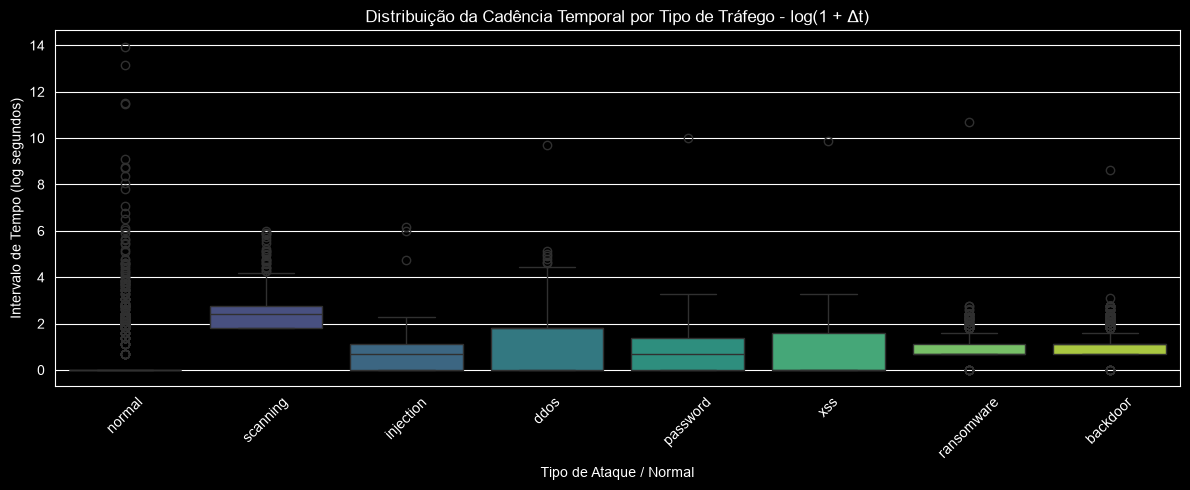

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Configuração visual
plt.figure(figsize=(12, 5))
df['log_delta_t'] = np.log1p(df['delta_t'])

# Boxplot por Tipo de Tráfego
sns.boxplot(
    data=df,
    x='type',
    y='log_delta_t',
    palette='viridis',
    hue='type',
    legend=False,
)
plt.title('Distribuição da Cadência Temporal por Tipo de Tráfego - log(1 + Δt)')
plt.xlabel('Tipo de Ataque / Normal')
plt.ylabel('Intervalo de Tempo (log segundos)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
from scipy import stats

# Separação dos grupos
delta_normal = df[df['label'] == 0]['delta_t']
delta_attack = df[df['label'] == 1]['delta_t']

# Execução do Teste Não-Paramétrico
stat, p_value = stats.mannwhitneyu(
    delta_normal, delta_attack, alternative='two-sided'
)

print("--- Teste de Hipótese de Mann-Whitney U ---")
print(f"Estatística U: {stat:.2f}")
print(f"p-valor: {p_value:.5e}")

if p_value < 0.05:
    print(
        "Conclusão: Diferença estatisticamente significativa entre Normal e Ataque (p < 0.05)."
    )
else:
    print("Conclusão: Sem diferença estatística relevante.")

--- Teste de Hipótese de Mann-Whitney U ---
Estatística U: 9464549121.50
p-valor: 0.00000e+00
Conclusão: Diferença estatisticamente significativa entre Normal e Ataque (p < 0.05).


In [23]:
from sklearn.feature_selection import mutual_info_classif

# Preparação rápida e temporária apenas para diagnóstico da EDA
X_temp = pd.DataFrame(
    {
        'door_state_encoded': df['door_state'].astype('category').cat.codes,
        'sphone_signal_encoded': df['sphone_signal']
        .astype(str)
        .astype('category')
        .cat.codes,
        'log_delta_t': df['log_delta_t'],
    }
)
y_temp = df['label']

# Cálculo do Mutual Information Score
mi_scores = mutual_info_classif(
    X_temp, y_temp, discrete_features=[0, 1], random_state=42
)
mi_df = pd.Series(mi_scores, index=X_temp.columns).sort_values(ascending=False)

print("--- Informação Mútua dos Recursos em Relação ao Alvo (label) ---")
print(mi_df)

--- Informação Mútua dos Recursos em Relação ao Alvo (label) ---
sphone_signal_encoded    0.172394
log_delta_t              0.105280
door_state_encoded       0.012258
dtype: float64
